# 🌳 Decision Trees (Árboles de Decisión)



---

## Contenido
1. [Definición y Aplicaciones](#1)
2. [Fundamentos Matemáticos](#2)
3. [Decision Tree desde Cero (NumPy)](#3)
4. [Clase DecisionTree Orientada a Objetos](#4)
5. [Decision Tree con Scikit-Learn](#5)
6. [Comparativa y Conclusiones](#6)

---
# 1. Definición y Aplicaciones

## ¿Qué es un Árbol de Decisión?

Un **árbol de decisión** es un algoritmo de aprendizaje supervisado que modela decisiones mediante una estructura de árbol jerárquica. Cada **nodo interno** representa una pregunta sobre una característica, cada **rama** representa el resultado de esa pregunta, y cada **nodo hoja** representa una clase (clasificación) o un valor (regresión).

La idea central es **dividir recursivamente** el espacio de características en regiones más puras, eligiendo en cada paso el corte que maximiza la homogeneidad de las clases resultantes.

### Anatomía de un árbol

```
              [Nodo Raíz]
             /           \
      [Nodo Interno]   [Nodo Interno]
       /       \           /      \
   [Hoja]   [Nodo]     [Hoja]   [Hoja]
             /   \
          [Hoja] [Hoja]
```

- **Nodo raíz**: Primera pregunta (feature más informativa)
- **Nodos internos**: Preguntas sobre features
- **Ramas**: Condiciones (≤ umbral / > umbral)
- **Hojas**: Predicciones finales

## Aplicaciones reales

| Dominio | Aplicación |
|---|---|
| 🏥 Medicina | Diagnóstico clínico y triage de pacientes |
| 💳 Finanzas | Scoring de crédito y aprobación de préstamos |
| 🛒 E-commerce | Sistemas de recomendación y segmentación |
| ⚖️ Legal | Predicción de resultados judiciales |
| 🌾 Agricultura | Clasificación de cultivos y predicción de cosechas |
| 🔧 Manufactura | Diagnóstico de fallos en maquinaria |
| 🎮 Videojuegos | IA para comportamiento de personajes (NPC) |

---
# 2. Fundamentos Matemáticos

## 2.1 Impureza de Gini

Mide la probabilidad de clasificar incorrectamente una muestra elegida al azar:

$$G(t) = 1 - \sum_{k=1}^{K} p_k^2$$

donde $p_k$ es la proporción de muestras de la clase $k$ en el nodo $t$, y $K$ es el número de clases.

- $G = 0$ → nodo **puro** (todas las muestras son de la misma clase)
- $G = 0.5$ → nodo con **máxima impureza** (clases equiprobables, para $K=2$)

## 2.2 Entropía de Shannon

Mide el nivel de desorden o incertidumbre en un nodo:

$$H(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

con la convención $0 \cdot \log_2(0) = 0$.

- $H = 0$ → nodo **puro**
- $H = \log_2(K)$ → máxima incertidumbre

## 2.3 Ganancia de Información

Al dividir el nodo $t$ en subconjuntos $t_L$ (izquierda) y $t_R$ (derecha) usando la característica $j$ con umbral $\theta$:

$$\text{IG}(t, j, \theta) = I(t) - \frac{N_L}{N}\, I(t_L) - \frac{N_R}{N}\, I(t_R)$$

donde:
- $I(\cdot)$ es la función de impureza (Gini o Entropía)
- $N$ es el número total de muestras en $t$
- $N_L, N_R$ son las muestras en cada rama

El algoritmo selecciona la división que **maximiza** $\text{IG}$:

$$j^*, \theta^* = \arg\max_{j, \theta}\; \text{IG}(t, j, \theta)$$

## 2.4 Error de Clasificación

Una tercera métrica de impureza, menos sensible:

$$E(t) = 1 - \max_k\, p_k$$

## 2.5 Comparación de métricas de impureza

Para un nodo binario con fracción de clase positiva $p$:

$$\text{Gini:}\quad G(p) = 2p(1-p)$$

$$\text{Entropía:}\quad H(p) = -p\log_2 p - (1-p)\log_2(1-p)$$

$$\text{Error:}\quad E(p) = 1 - \max(p, 1-p)$$

## 2.6 Predicción en regresión: Varianza

Para árboles de regresión, la impureza se mide con la varianza del nodo:

$$\text{Var}(t) = \frac{1}{N}\sum_{i=1}^{N}(y_i - \bar{y})^2$$

La predicción en una hoja es la **media** de los valores objetivo:

$$\hat{y} = \bar{y}_t = \frac{1}{N_t}\sum_{i \in t} y_i$$

## 2.7 Poda (Pruning)

Para evitar sobreajuste, se aplica **poda por complejidad de coste** (*cost-complexity pruning*):

$$R_\alpha(T) = R(T) + \alpha\, |T|$$

donde:
- $R(T)$ es el error de entrenamiento del árbol $T$
- $|T|$ es el número de hojas
- $\alpha \geq 0$ es el parámetro de regularización (penaliza la complejidad)

---
# 3. Decision Tree desde Cero (con NumPy)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import Counter

from sklearn.datasets import load_iris, load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# ── Estilo de gráficos ────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})

PALETTE = ['#58a6ff', '#ff7b72', '#3fb950', '#d2a8ff',
           '#ffa657', '#79c0ff', '#f85149', '#56d364']

print('✅ Librerías importadas')

✅ Librerías importadas


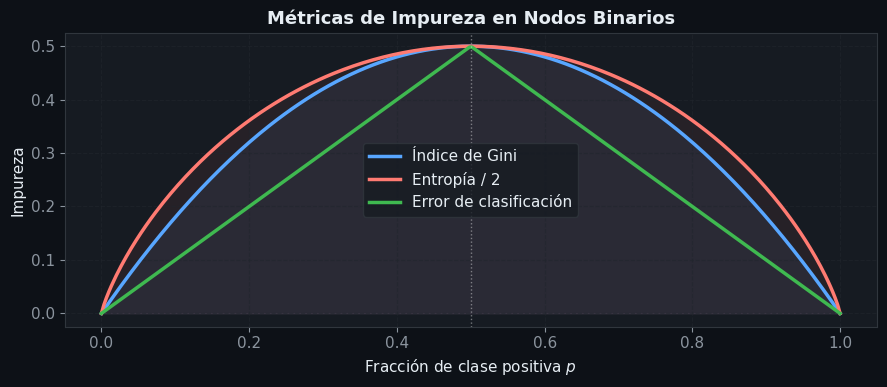

In [2]:
# ============================================================
#  VISUALIZACIÓN: Comparación de métricas de impureza
# ============================================================

p = np.linspace(1e-9, 1 - 1e-9, 300)

gini    = 2 * p * (1 - p)
entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
error   = 1 - np.maximum(p, 1 - p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(p, gini,        color=PALETTE[0], lw=2.5, label='Índice de Gini')
ax.plot(p, entropy / 2, color=PALETTE[1], lw=2.5, label='Entropía / 2')
ax.plot(p, error,       color=PALETTE[2], lw=2.5, label='Error de clasificación')
ax.fill_between(p, gini,        alpha=0.07, color=PALETTE[0])
ax.fill_between(p, entropy / 2, alpha=0.07, color=PALETTE[1])
ax.axvline(0.5, color='white', lw=1, ls=':', alpha=0.4)
ax.set_xlabel('Fracción de clase positiva $p$')
ax.set_ylabel('Impureza')
ax.set_title('Métricas de Impureza en Nodos Binarios')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('dt_impureza.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [4]:
# ============================================================
#  FUNCIONES BASE — Decision Tree desde Cero
# ============================================================

def gini_impurity(y):
    """Impureza de Gini para un nodo."""
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs  = counts / len(y)
    return 1.0 - np.sum(probs ** 2)


def entropy(y):
    """Entropía de Shannon para un nodo."""
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs  = counts[counts > 0] / len(y)
    return -np.sum(probs * np.log2(probs))


def information_gain(y, y_left, y_right, criterion='gini'):
    """Ganancia de información de una división."""
    impurity_fn = gini_impurity if criterion == 'gini' else entropy
    N  = len(y)
    NL, NR = len(y_left), len(y_right)
    return (impurity_fn(y)
            - (NL / N) * impurity_fn(y_left)
            - (NR / N) * impurity_fn(y_right))


def best_split(X, y, criterion='gini'):
    """
    Encuentra la mejor división (feature, umbral) maximizando la
    ganancia de información.

    Retorna: (best_feature_idx, best_threshold, best_gain)
    """
    best_gain  = -np.inf
    best_feat  = None
    best_thr   = None
    n_features = X.shape[1]

    for feat_idx in range(n_features):
        thresholds = np.unique(X[:, feat_idx])
        for thr in thresholds:
            left_mask  = X[:, feat_idx] <= thr
            right_mask = ~left_mask

            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            gain = information_gain(y, y[left_mask], y[right_mask], criterion)
            if gain > best_gain:
                best_gain = gain
                best_feat = feat_idx
                best_thr  = thr

    return best_feat, best_thr, best_gain


def build_tree(X, y, depth=0, max_depth=5, min_samples_split=2,
               criterion='gini', feature_names=None):
    """
    Construye recursivamente el árbol de decisión.
    Retorna un diccionario que representa el nodo.
    """
    n_samples = len(y)
    n_classes = len(np.unique(y))
    majority  = Counter(y).most_common(1)[0][0]

    # ── Condiciones de parada ──────────────────────────────
    if (depth >= max_depth
            or n_classes == 1
            or n_samples < min_samples_split):
        return {
            'leaf': True,
            'prediction': majority,
            'samples': n_samples,
            'counts': dict(Counter(y)),
        }

    feat, thr, gain = best_split(X, y, criterion)

    # Sin ganancia → hoja
    if feat is None or gain <= 0:
        return {
            'leaf': True,
            'prediction': majority,
            'samples': n_samples,
            'counts': dict(Counter(y)),
        }

    left_mask  = X[:, feat] <= thr
    right_mask = ~left_mask

    feat_label = feature_names[feat] if feature_names is not None else f'X[{feat}]'

    return {
        'leaf':        False,
        'feature':     feat,
        'feature_name': feat_label,
        'threshold':   thr,
        'gain':        gain,
        'samples':     n_samples,
        'prediction':  majority,
        'depth':       depth,
        'left':  build_tree(X[left_mask],  y[left_mask],
                            depth+1, max_depth, min_samples_split,
                            criterion, feature_names),
        'right': build_tree(X[right_mask], y[right_mask],
                            depth+1, max_depth, min_samples_split,
                            criterion, feature_names),
    }


def predict_sample(node, x):
    """Predice la clase para una sola muestra recorriendo el árbol."""
    if node['leaf']:
        return node['prediction']
    if x[node['feature']] <= node['threshold']:
        return predict_sample(node['left'], x)
    else:
        return predict_sample(node['right'], x)


def predict_tree(node, X):
    """Predice para un array completo de muestras."""
    return np.array([predict_sample(node, x) for x in X])


def print_tree(node, indent='', feature_names=None, class_names=None):
    """Imprime el árbol de forma legible."""
    if node['leaf']:
        cls = class_names[node['prediction']] if class_names else node['prediction']
        print(f"{indent}🍃 Hoja → Clase: {cls} | Muestras: {node['samples']}")
        return
    print(f"{indent}🔀 {node['feature_name']} ≤ {node['threshold']:.4f} "
          f"(Ganancia={node['gain']:.4f}, n={node['samples']})")
    print(f"{indent}  ├─ SÍ →")
    print_tree(node['left'],  indent + '  │   ', feature_names, class_names)
    print(f"{indent}  └─ NO →")
    print_tree(node['right'], indent + '      ', feature_names, class_names)



In [5]:
# ============================================================
#  ENTRENAMIENTO desde Cero — Dataset Iris
# ============================================================

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
feat_names  = iris.feature_names
class_names = list(iris.target_names)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=42, stratify=y_iris)

# Construir árbol
tree = build_tree(X_tr, y_tr, max_depth=4,
                  min_samples_split=4,
                  criterion='gini',
                  feature_names=feat_names)

# Predicciones
y_pred_tr = predict_tree(tree, X_tr)
y_pred_te = predict_tree(tree, X_te)

acc_tr = np.mean(y_pred_tr == y_tr)
acc_te = np.mean(y_pred_te == y_te)

print('='*50)
print('RESULTADOS — Decision Tree desde Cero (Iris)')
print('='*50)
print(f' Accuracy Train : {acc_tr:.4f}')
print(f'Accuracy Test  : {acc_te:.4f}')
print()
print('Estructura del árbol:')
print('-'*50)
print_tree(tree, class_names=class_names)

   RESULTADOS — Decision Tree desde Cero (Iris)
  Accuracy Train : 0.9821
  Accuracy Test  : 0.9211

Estructura del árbol:
--------------------------------------------------
🔀 petal length (cm) ≤ 1.9000 (Ganancia=0.3363, n=112)
  ├─ SÍ →
  │   🍃 Hoja → Clase: setosa | Muestras: 38
  └─ NO →
      🔀 petal length (cm) ≤ 4.8000 (Ganancia=0.3989, n=74)
        ├─ SÍ →
        │   🔀 petal width (cm) ≤ 1.5000 (Ganancia=0.0269, n=35)
        │     ├─ SÍ →
        │     │   🍃 Hoja → Clase: versicolor | Muestras: 33
        │     └─ NO →
        │         🍃 Hoja → Clase: virginica | Muestras: 2
        └─ NO →
            🔀 petal width (cm) ≤ 1.6000 (Ganancia=0.0651, n=39)
              ├─ SÍ →
              │   🔀 petal length (cm) ≤ 4.9000 (Ganancia=0.2500, n=6)
              │     ├─ SÍ →
              │     │   🍃 Hoja → Clase: versicolor | Muestras: 2
              │     └─ NO →
              │         🍃 Hoja → Clase: virginica | Muestras: 4
              └─ NO →
                  🍃 Hoja → C

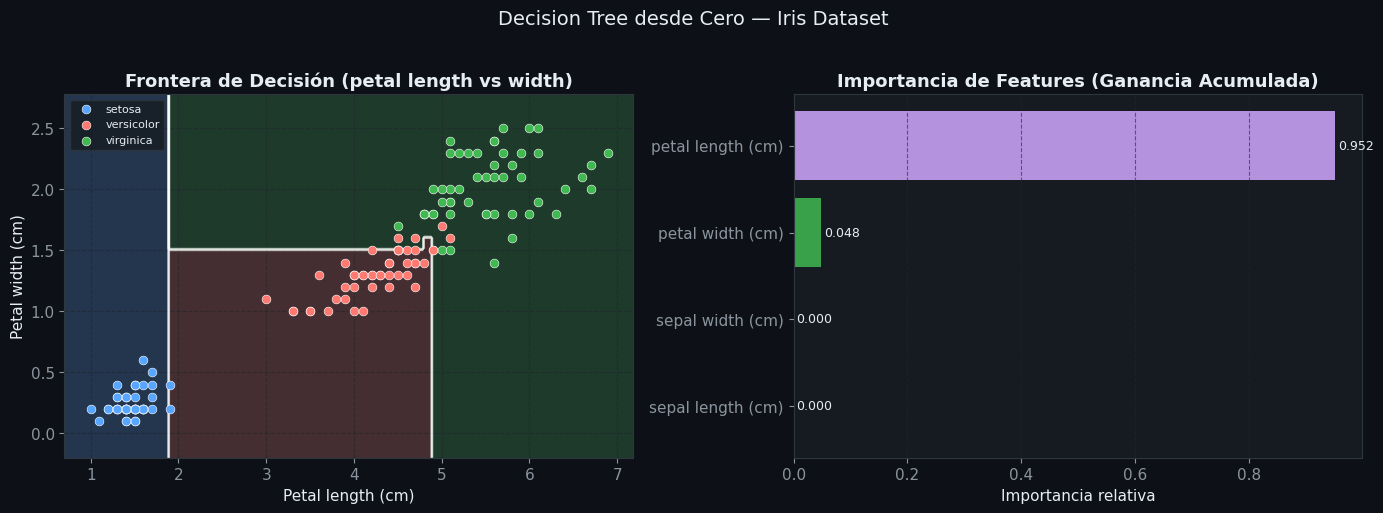

In [6]:
# ============================================================
#  GRÁFICO — Frontera de decisión (2 features) + Ganancia
# ============================================================

# Usamos solo 2 features para visualizar
X2 = X_iris[:, 2:4]   # petal length & petal width
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y_iris, test_size=0.25, random_state=42, stratify=y_iris)

tree2d = build_tree(X2_tr, y2_tr, max_depth=4,
                    criterion='gini',
                    feature_names=['petal length', 'petal width'])


def plot_decision_boundary_tree(tree_node, X, y, ax, title=''):
    h = 0.02
    xm, xM = X[:, 0].min()-0.3, X[:, 0].max()+0.3
    ym, yM = X[:, 1].min()-0.3, X[:, 1].max()+0.3
    xx, yy = np.meshgrid(np.arange(xm, xM, h), np.arange(ym, yM, h))
    Z = predict_tree(tree_node, np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg = ListedColormap([PALETTE[0] + '33', PALETTE[1] + '33', PALETTE[2] + '33'])
    ax.contourf(xx, yy, Z, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=1.2, alpha=0.5)

    for cls, col, name in zip(range(3), PALETTE[:3], class_names):
        m = y == cls
        ax.scatter(X[m, 0], X[m, 1], c=col, s=40,
                   edgecolors='white', lw=0.4, zorder=5, label=name)

    ax.set_xlabel('Petal length (cm)')
    ax.set_ylabel('Petal width (cm)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Tree desde Cero — Iris Dataset', fontsize=14, y=1.02)

plot_decision_boundary_tree(tree2d, X2, y_iris, axes[0],
                             title='Frontera de Decisión (petal length vs width)')

# Importancia de features aproximada (basada en ganancia acumulada)
gains = {
    feat_names[2]: 0.0,
    feat_names[3]: 0.0,
    feat_names[0]: 0.0,
    feat_names[1]: 0.0,
}

def collect_gains(node, gains_dict):
    if node['leaf']:
        return
    fname = node['feature_name']
    if fname in gains_dict:
        gains_dict[fname] += node['gain'] * node['samples']
    collect_gains(node['left'],  gains_dict)
    collect_gains(node['right'], gains_dict)

collect_gains(tree, gains)
total = sum(gains.values()) + 1e-10
norm_gains = {k: v / total for k, v in gains.items()}

sorted_gains = dict(sorted(norm_gains.items(), key=lambda x: x[1]))
bars = axes[1].barh(list(sorted_gains.keys()), list(sorted_gains.values()),
                    color=PALETTE[:4], alpha=0.85)
axes[1].set_title('Importancia de Features (Ganancia Acumulada)')
axes[1].set_xlabel('Importancia relativa')
axes[1].grid(True, axis='x')
for bar, val in zip(bars, sorted_gains.values()):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('dt_scratch_resultado.png', dpi=120,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 4. Clase DecisionTree Orientada a Objetos

Encapsulamos toda la lógica en una clase con API compatible con Scikit-Learn.

In [7]:
# ============================================================
#  CLASE DecisionTreeClasificador — Implementación OOP
# ============================================================

class Nodo:
    """Nodo individual del árbol."""

    def __init__(self):
        self.leaf = False
        self.feature  = None
        self.threshold  = None
        self.gain = None
        self.prediction = None
        self.samples = None
        self.impurity = None
        self.left = None
        self.right = None
        self.depth = None

class DecisionTreeClasificador:
    """
    Parámetros
    ----------
    max_depth         : int   — profundidad máxima del árbol
    min_samples_split : int   — mínimo de muestras para dividir un nodo
    min_samples_leaf  : int   — mínimo de muestras en una hoja
    criterion         : str   — 'gini' o 'entropy'
    """

    def __init__(self, max_depth=10, min_samples_split=2,
                 min_samples_leaf=1, criterion='gini'):
        self.max_depth          = max_depth
        self.min_samples_split  = min_samples_split
        self.min_samples_leaf   = min_samples_leaf
        self.criterion          = criterion
        self.root_= None
        self.n_features_ = None
        self.classes_ = None
        self.feature_importances_ = None
        self._feature_gains = None

    # ── Métricas de impureza ───────────────────────────────

    def _impurity(self, y):
        if len(y) == 0:
            return 0.0
        counts = np.bincount(y, minlength=len(self.classes_))
        probs  = counts / len(y)
        if self.criterion == 'gini':
            return 1.0 - np.sum(probs ** 2)
        else:  # entropy
            mask = probs > 0
            return -np.sum(probs[mask] * np.log2(probs[mask]))

    def _information_gain(self, y, y_left, y_right):
        N, NL, NR = len(y), len(y_left), len(y_right)
        return (self._impurity(y)
                - (NL / N) * self._impurity(y_left)
                - (NR / N) * self._impurity(y_right))

    # ── Búsqueda de la mejor división ─────────────────────

    def _best_split(self, X, y):
        best_gain = -np.inf
        best_feat = best_thr = None

        for feat in range(self.n_features_):
            thresholds = np.unique(X[:, feat])
            # Probar puntos medios entre valores consecutivos
            midpoints  = (thresholds[:-1] + thresholds[1:]) / 2
            if len(midpoints) == 0:
                midpoints = thresholds

            for thr in midpoints:
                lm = X[:, feat] <= thr
                rm = ~lm
                if (lm.sum() < self.min_samples_leaf
                        or rm.sum() < self.min_samples_leaf):
                    continue
                gain = self._information_gain(y, y[lm], y[rm])
                if gain > best_gain:
                    best_gain, best_feat, best_thr = gain, feat, thr

        return best_feat, best_thr, best_gain

    # ── Construcción recursiva ─────────────────────────────

    def _build(self, X, y, depth):
        node = Nodo()
        node.samples  = len(y)
        node.impurity = self._impurity(y)
        node.depth = depth
        node.prediction = np.argmax(np.bincount(y, minlength=len(self.classes_)))

        # Condiciones de parada
        stop = (depth >= self.max_depth
                or len(np.unique(y)) == 1
                or len(y) < self.min_samples_split)

        if not stop:
            feat, thr, gain = self._best_split(X, y)
            if feat is not None and gain > 0:
                node.feature   = feat
                node.threshold = thr
                node.gain      = gain
                self._feature_gains[feat] += gain * len(y)

                lm = X[:, feat] <= thr
                node.left = self._build(X[lm],  y[lm],  depth + 1)
                node.right= self._build(X[~lm], y[~lm], depth + 1)
                return node

        node.leaf = True
        return node



    def fit(self, X, y):
        """
        Entrena el árbol.
        """
        X, y = np.array(X), np.array(y, dtype=int)
        self.classes_ = np.unique(y)
        self.n_features_  = X.shape[1]
        self._feature_gains = np.zeros(self.n_features_)

        self.root_ = self._build(X, y, depth=0)

        total = self._feature_gains.sum() + 1e-10
        self.feature_importances_ = self._feature_gains / total
        return self

    def _predict_one(self, node, x):
        if node.leaf or node.feature is None:
            return node.prediction
        if x[node.feature] <= node.threshold:
            return self._predict_one(node.left, x)
        return self._predict_one(node.right, x)

    def predict(self, X):
        """Predice clases para el array X."""
        return np.array([self._predict_one(self.root_, x) for x in np.array(X)])

    def score(self, X, y):
        """Accuracy del modelo."""
        return np.mean(self.predict(X) == np.array(y, dtype=int))

    def get_depth(self):
        """Profundidad máxima alcanzada."""
        def _depth(node):
            if node is None or node.leaf:
                return 0
            return 1 + max(_depth(node.left), _depth(node.right))
        return _depth(self.root_)

    def get_n_leaves(self):
        """Número de hojas del árbol."""
        def _leaves(node):
            if node is None or node.leaf:
                return 1
            return _leaves(node.left) + _leaves(node.right)
        return _leaves(self.root_)

    def __repr__(self):
        return (f'DecisionTreeClasificador('
                f'max_depth={self.max_depth}, '
                f'criterion={self.criterion!r})')


print('✅ Clase DecisionTreeClasificador definida')
print(DecisionTreeClasificador())

✅ Clase DecisionTreeClasificador definida
DecisionTreeClasificador(max_depth=10, criterion='gini')


In [8]:
# ============================================================
#  PRUEBA DE LA CLASE — Iris + comparativa de profundidades
# ============================================================

depths = [1, 2, 3, 4, 5, 7, 10]
results = []

print(f'{"max_depth":<12} {"Train Acc":>12} {"Test Acc":>12} {"Hojas":>8} {"Profundidad real":>18}')
print('-' * 66)

for d in depths:
    clf = DecisionTreeClasificador(max_depth=d, criterion='gini')
    clf.fit(X_tr, y_tr)
    tr_a = clf.score(X_tr, y_tr)
    te_a = clf.score(X_te, y_te)
    results.append({'depth': d, 'train': tr_a, 'test': te_a,
                    'leaves': clf.get_n_leaves(),
                    'real_depth': clf.get_depth()})
    print(f'{d:<12} {tr_a:>12.4f} {te_a:>12.4f} {clf.get_n_leaves():>8} {clf.get_depth():>18}')

max_depth       Train Acc     Test Acc    Hojas   Profundidad real
------------------------------------------------------------------
1                  0.6696       0.6579        2                  1
2                  0.9643       0.9211        3                  2
3                  0.9643       0.9211        5                  3
4                  0.9911       0.9211        7                  4
5                  0.9911       0.8947        8                  5
7                  1.0000       0.8947        9                  6
10                 1.0000       0.8947        9                  6


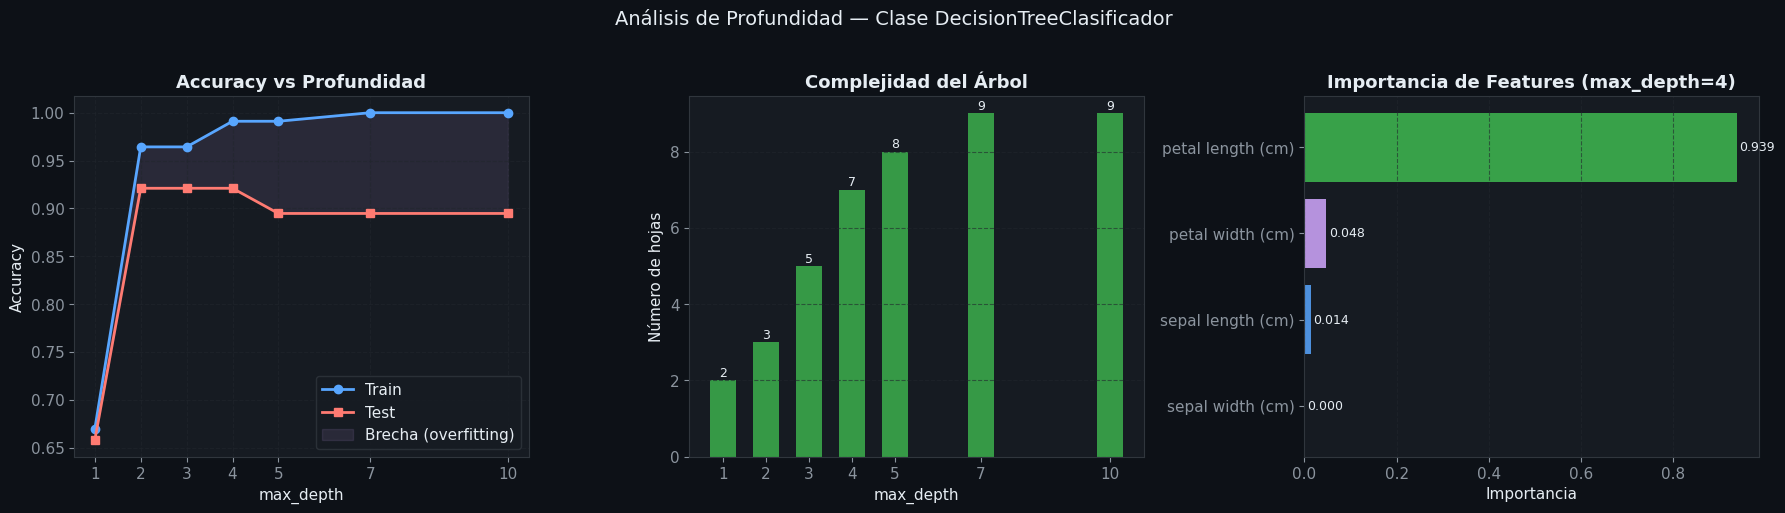

In [9]:
# ============================================================
#  GRÁFICOS — Clase OOP
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Profundidad — Clase DecisionTreeClasificador', fontsize=14, y=1.02)

# ── 1. Accuracy vs profundidad ──────────────────────────────
ds = [r['depth'] for r in results]
tr_acc = [r['train'] for r in results]
te_acc = [r['test']  for r in results]

axes[0].plot(ds, tr_acc, 'o-', color=PALETTE[0], lw=2, label='Train')
axes[0].plot(ds, te_acc, 's-', color=PALETTE[1], lw=2, label='Test')
axes[0].fill_between(ds, tr_acc, te_acc, alpha=0.1, color=PALETTE[3],
                     label='Brecha (overfitting)')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Profundidad')
axes[0].legend()
axes[0].grid(True)
axes[0].set_xticks(ds)

# ── 2. Número de hojas vs profundidad ───────────────────────
leaves = [r['leaves'] for r in results]
axes[1].bar(ds, leaves, color=PALETTE[2], alpha=0.8, width=0.6)
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Número de hojas')
axes[1].set_title('Complejidad del Árbol')
axes[1].grid(True, axis='y')
axes[1].set_xticks(ds)
for i, (d, l) in enumerate(zip(ds, leaves)):
    axes[1].text(d, l + 0.1, str(l), ha='center', fontsize=9)

# ── 3. Importancia de features (max_depth=4) ────────────────
clf_best = DecisionTreeClasificador(max_depth=4, criterion='gini')
clf_best.fit(X_tr, y_tr)
importances = clf_best.feature_importances_
sorted_idx  = np.argsort(importances)
colors_fi   = [PALETTE[i % len(PALETTE)] for i in range(len(feat_names))]

bars = axes[2].barh([feat_names[i] for i in sorted_idx],
                     importances[sorted_idx],
                     color=[colors_fi[i] for i in sorted_idx], alpha=0.85)
axes[2].set_xlabel('Importancia')
axes[2].set_title('Importancia de Features (max_depth=4)')
axes[2].grid(True, axis='x')
for bar, val in zip(bars, importances[sorted_idx]):
    axes[2].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('dt_clase_analisis.png', dpi=120,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

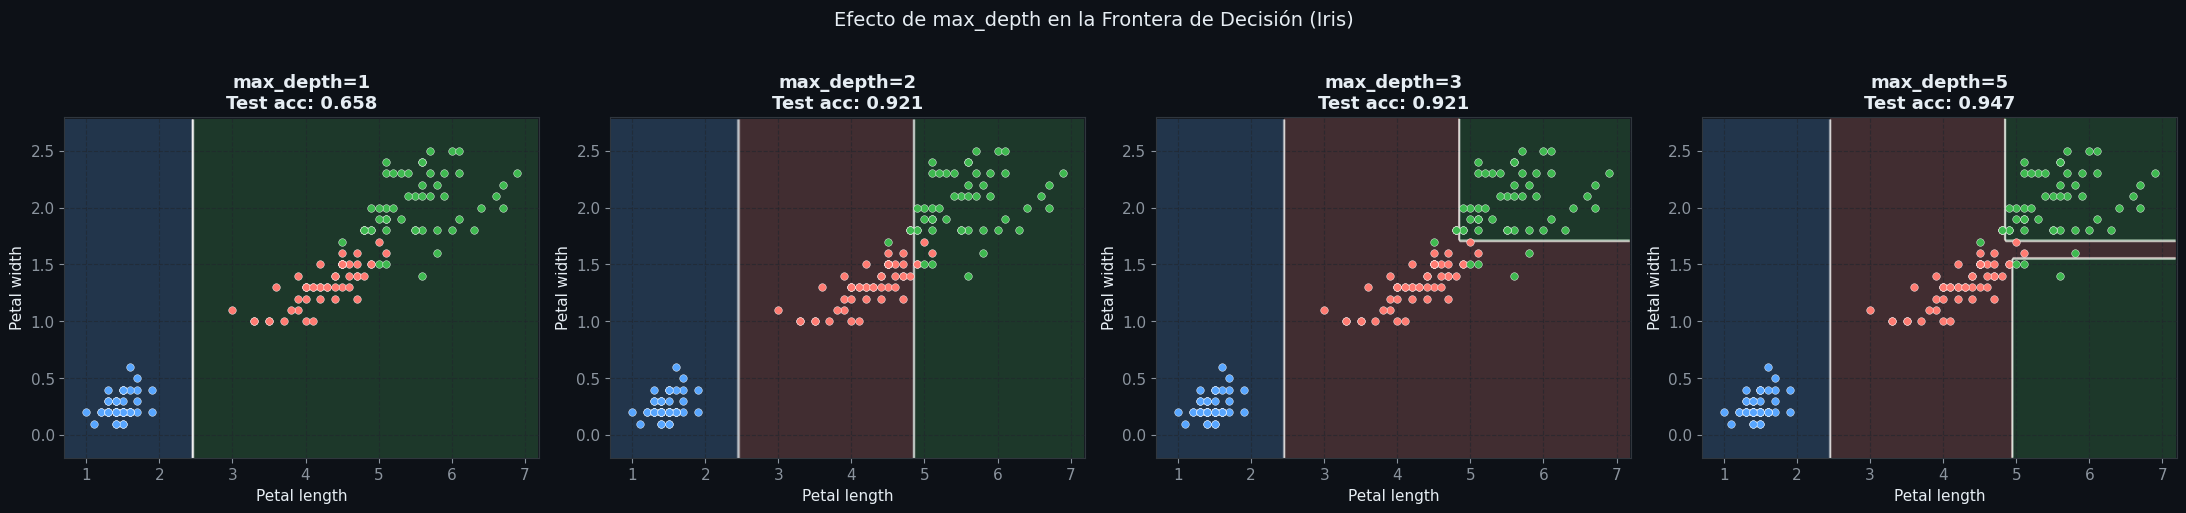

In [10]:
# ── Fronteras para distintas profundidades (2 features) ──────

depths_vis = [1, 2, 3, 5]
fig, axes  = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Efecto de max_depth en la Frontera de Decisión (Iris)',
             fontsize=14, y=1.02)

for ax, d in zip(axes, depths_vis):
    clf_d = DecisionTreeClasificador(max_depth=d, criterion='gini')
    clf_d.fit(X2_tr, y2_tr)
    acc_d = clf_d.score(X2_te, y2_te)

    h = 0.02
    xm, xM = X2[:, 0].min()-0.3, X2[:, 0].max()+0.3
    ym, yM = X2[:, 1].min()-0.3, X2[:, 1].max()+0.3
    xx, yy = np.meshgrid(np.arange(xm, xM, h), np.arange(ym, yM, h))
    Z = clf_d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg = ListedColormap([PALETTE[0] + '30', PALETTE[1] + '30', PALETTE[2] + '30'])
    ax.contourf(xx, yy, Z, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=1, alpha=0.4)

    for cls, col in zip(range(3), PALETTE[:3]):
        m = y_iris == cls
        ax.scatter(X2[m, 0], X2[m, 1], c=col, s=30,
                   edgecolors='white', lw=0.3, zorder=5)

    ax.set_title(f'max_depth={d}\nTest acc: {acc_d:.3f}')
    ax.set_xlabel('Petal length')
    ax.set_ylabel('Petal width')
    ax.grid(True)
    ax.set_xlim(xm, xM)
    ax.set_ylim(ym, yM)

plt.tight_layout()
plt.savefig('dt_profundidades.png', dpi=110,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 5. Decision Tree con Scikit-Learn

Usaremos el dataset **Breast Cancer Wisconsin** y exploraremos todas las capacidades de Scikit-Learn: visualización del árbol, poda, validación cruzada y optimización de hiperparámetros.

In [11]:
# ============================================================
#  DATASET: Breast Cancer Wisconsin
# ============================================================

bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
bc_feat = bc.feature_names
bc_classes = bc.target_names

X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42)

print(f'Dataset  : Breast Cancer Wisconsin')
print(f'Muestras : {X_bc.shape[0]}')
print(f'Features : {X_bc.shape[1]}')
print(f'Clases   : {bc_classes} → {np.bincount(y_bc)}')
print(f'Train    : {len(X_bc_tr)} | Test: {len(X_bc_te)}')

Dataset  : Breast Cancer Wisconsin
Muestras : 569
Features : 30
Clases   : ['malignant' 'benign'] → [212 357]
Train    : 455 | Test: 114


In [12]:
# ============================================================
#  Entrenar y visualizar el árbol
# ============================================================

dt_sk = DecisionTreeClassifier(max_depth=4, criterion='gini',
                                min_samples_split=10, random_state=42)
dt_sk.fit(X_bc_tr, y_bc_tr)

y_pred_bc = dt_sk.predict(X_bc_te)

print('='*55)
print('   RESULTADOS — Scikit-Learn DecisionTree (Breast Cancer)')
print('='*55)
print(f'  Accuracy Train : {dt_sk.score(X_bc_tr, y_bc_tr):.4f}')
print(f'  Accuracy Test  : {dt_sk.score(X_bc_te, y_bc_te):.4f}')
print(f'  Profundidad    : {dt_sk.get_depth()}')
print(f'  Hojas          : {dt_sk.get_n_leaves()}')
print()
print(classification_report(y_bc_te, y_pred_bc, target_names=bc_classes))

   RESULTADOS — Scikit-Learn DecisionTree (Breast Cancer)
  Accuracy Train : 0.9824
  Accuracy Test  : 0.9298
  Profundidad    : 4
  Hojas          : 10

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



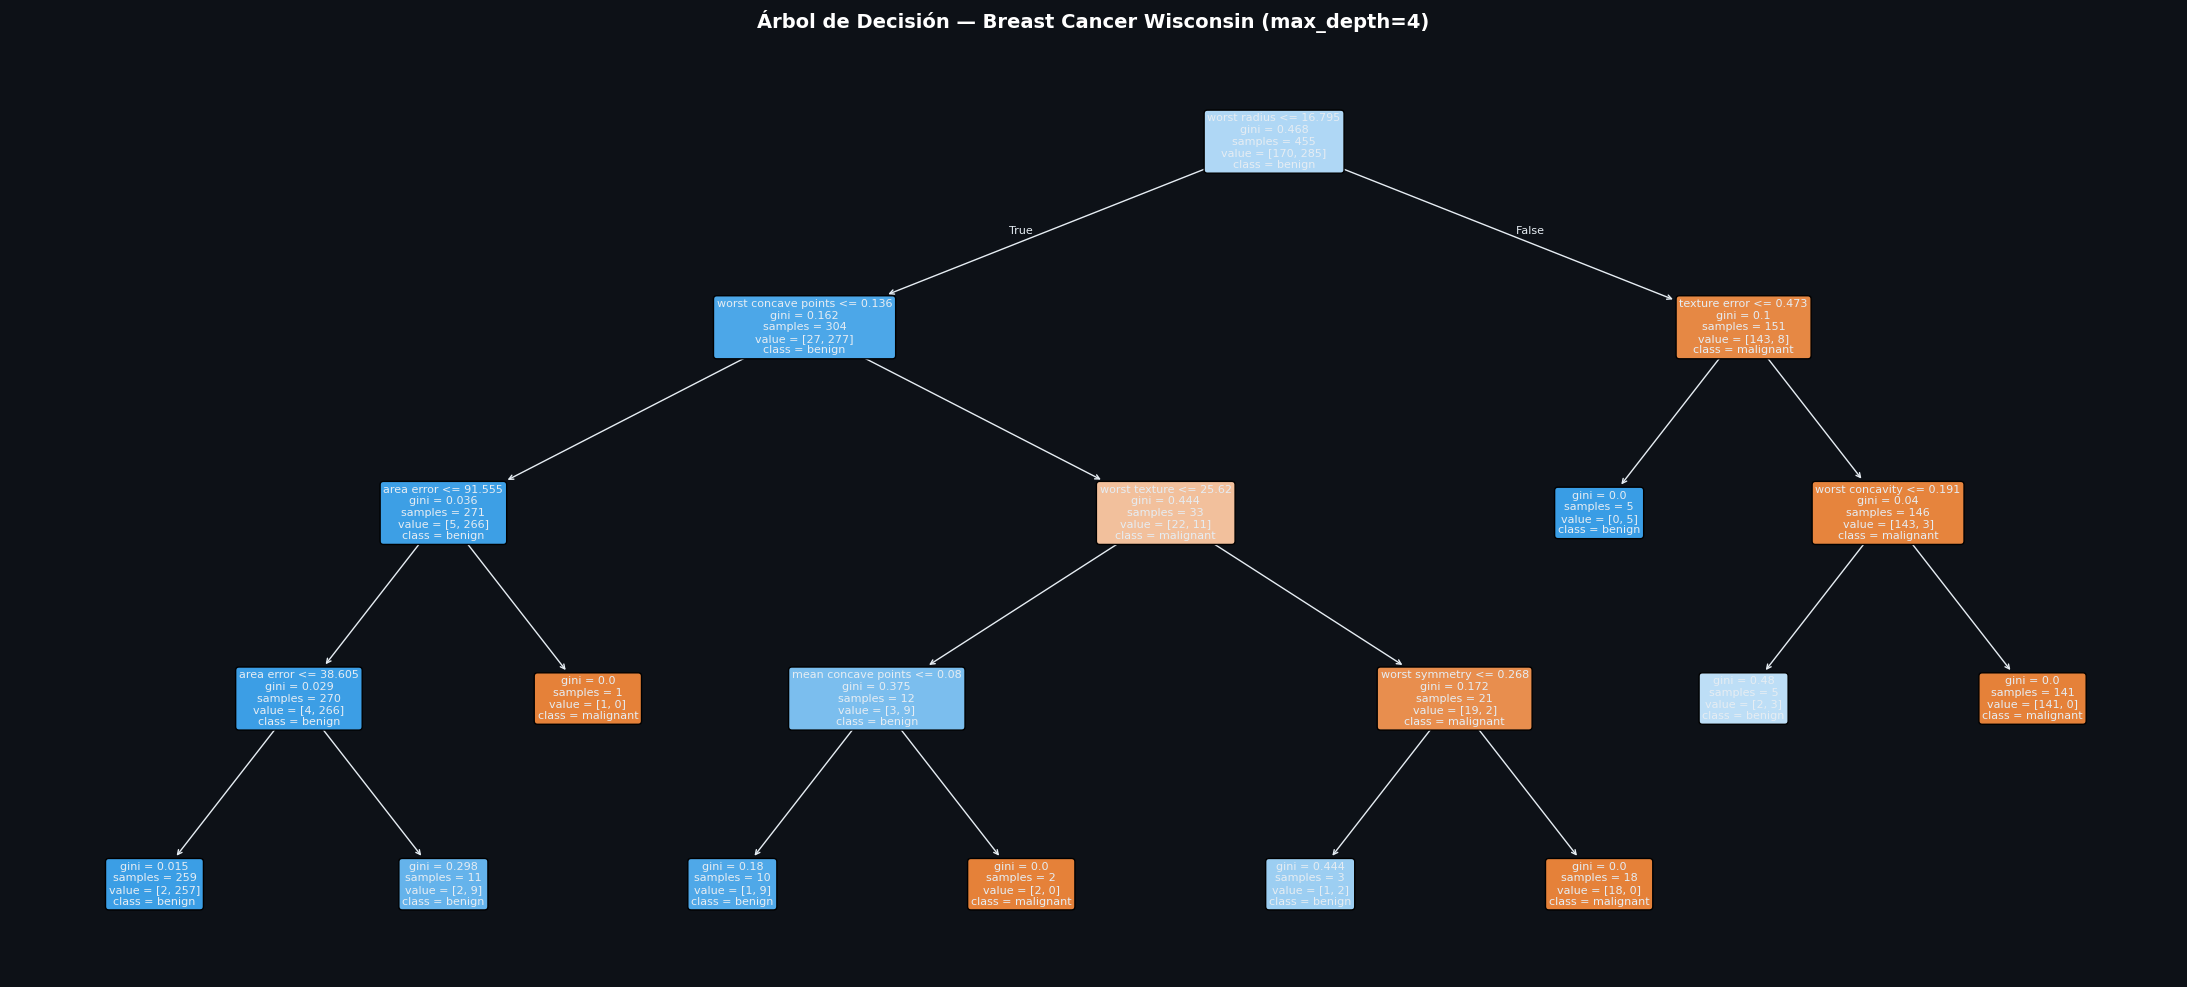


Representación textual (primeras 3 hojas):
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- truncated branch of depth 2
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- truncated branch of depth 2
|   |   |--- worst texture >  25.62
|   |   |   |--- truncated branch of depth 2
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



In [13]:
# ============================================================
#  VISUALIZACIÓN DEL ÁRBOL — Scikit-Learn
# ============================================================

fig, ax = plt.subplots(figsize=(22, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

plot_tree(
    dt_sk,
    feature_names=bc_feat,
    class_names=bc_classes,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False,
)
ax.set_title('Árbol de Decisión — Breast Cancer Wisconsin (max_depth=4)',
             fontsize=14, color='white', pad=15)

plt.tight_layout()
plt.savefig('dt_sklearn_arbol.png', dpi=110,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Versión texto
print('\nRepresentación textual (primeras 3 hojas):')
print(export_text(dt_sk, feature_names=list(bc_feat), max_depth=2))

In [14]:
# ============================================================
#  PODA Y VALIDACIÓN CRUZADA
# ============================================================

# 1. Poda por complejidad de coste (ccp_alpha)
path    = dt_sk.cost_complexity_pruning_path(X_bc_tr, y_bc_tr)
ccp_alphas = path.ccp_alphas[:-1]   # excluir el árbol trivial
impurities = path.impurities[:-1]

# Entrenar árboles para cada alpha
clfs_pruned = []
for alpha in ccp_alphas:
    clf_p = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf_p.fit(X_bc_tr, y_bc_tr)
    clfs_pruned.append(clf_p)

train_acc_p = [c.score(X_bc_tr, y_bc_tr) for c in clfs_pruned]
test_acc_p  = [c.score(X_bc_te, y_bc_te) for c in clfs_pruned]
n_leaves_p  = [c.get_n_leaves()           for c in clfs_pruned]

# 2. Validación cruzada por profundidad
depths_cv = range(1, 15)
cv_scores  = []
for d in depths_cv:
    clf_cv = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(clf_cv, X_bc, y_bc, cv=5, scoring='accuracy')
    cv_scores.append({'depth': d, 'mean': scores.mean(), 'std': scores.std()})

best_depth = max(cv_scores, key=lambda x: x['mean'])['depth']
print(f'Mejor profundidad (5-fold CV): {best_depth}')

Mejor profundidad (5-fold CV): 2


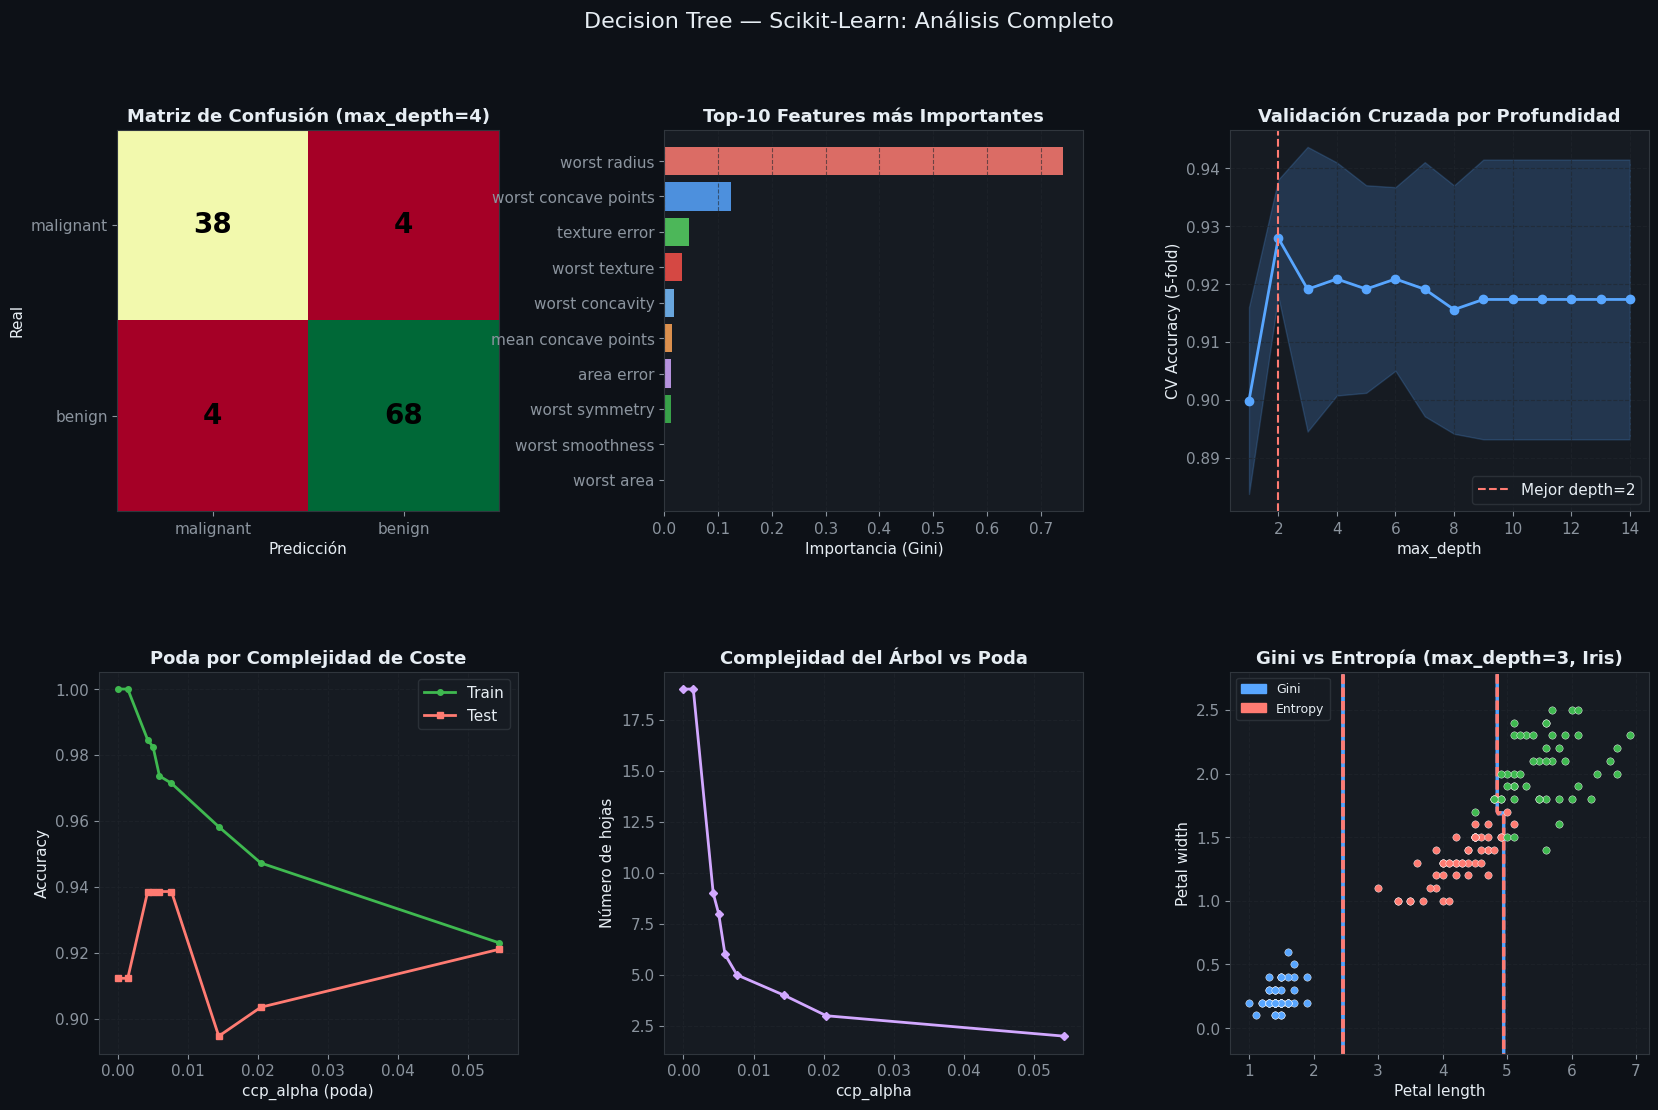

✅ Gráficos guardados


In [15]:
# ============================================================
#  GRÁFICOS — Scikit-Learn
# ============================================================

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Decision Tree — Scikit-Learn: Análisis Completo', fontsize=16)
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)

# ── 1. Matriz de confusión ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_bc_te, y_pred_bc)
im  = ax1.imshow(cm, cmap='RdYlGn', interpolation='nearest')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=20, fontweight='bold', color='black')
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(bc_classes); ax1.set_yticklabels(bc_classes)
ax1.set_title('Matriz de Confusión (max_depth=4)')
ax1.set_xlabel('Predicción'); ax1.set_ylabel('Real')

# ── 2. Importancia de features (top 10) ─────────────────────
ax2 = fig.add_subplot(gs[0, 1])
imp_idx = np.argsort(dt_sk.feature_importances_)[-10:]
bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(imp_idx))]
ax2.barh([bc_feat[i] for i in imp_idx],
          dt_sk.feature_importances_[imp_idx],
          color=bar_colors, alpha=0.85)
ax2.set_title('Top-10 Features más Importantes')
ax2.set_xlabel('Importancia (Gini)')
ax2.grid(True, axis='x')

# ── 3. Validación cruzada (profundidad) ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cv_means = [s['mean'] for s in cv_scores]
cv_stds  = [s['std']  for s in cv_scores]
ax3.plot(list(depths_cv), cv_means, 'o-', color=PALETTE[0], lw=2)
ax3.fill_between(list(depths_cv),
                 [m - s for m, s in zip(cv_means, cv_stds)],
                 [m + s for m, s in zip(cv_means, cv_stds)],
                 alpha=0.2, color=PALETTE[0])
ax3.axvline(best_depth, color=PALETTE[1], ls='--', lw=1.5,
            label=f'Mejor depth={best_depth}')
ax3.set_xlabel('max_depth')
ax3.set_ylabel('CV Accuracy (5-fold)')
ax3.set_title('Validación Cruzada por Profundidad')
ax3.legend()
ax3.grid(True)

# ── 4. Poda: accuracy vs alpha ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(ccp_alphas, train_acc_p, 'o-', color=PALETTE[2], lw=2, label='Train', ms=4)
ax4.plot(ccp_alphas, test_acc_p,  's-', color=PALETTE[1], lw=2, label='Test',  ms=4)
ax4.set_xlabel('ccp_alpha (poda)')
ax4.set_ylabel('Accuracy')
ax4.set_title('Poda por Complejidad de Coste')
ax4.legend()
ax4.grid(True)

# ── 5. Poda: hojas vs alpha ──────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(ccp_alphas, n_leaves_p, 'D-', color=PALETTE[3], lw=2, ms=4)
ax5.set_xlabel('ccp_alpha')
ax5.set_ylabel('Número de hojas')
ax5.set_title('Complejidad del Árbol vs Poda')
ax5.grid(True)

# ── 6. Fronteras: criterio gini vs entropy ───────────────────
# Usamos Iris 2D para visualizar
ax6 = fig.add_subplot(gs[1, 2])
h   = 0.02
xm, xM = X2[:, 0].min()-0.3, X2[:, 0].max()+0.3
ym, yM = X2[:, 1].min()-0.3, X2[:, 1].max()+0.3
xx, yy = np.meshgrid(np.arange(xm, xM, h), np.arange(ym, yM, h))

for crit, ls, col in [('gini', '-', PALETTE[0]), ('entropy', '--', PALETTE[1])]:
    clf_c = DecisionTreeClassifier(max_depth=3, criterion=crit, random_state=42)
    clf_c.fit(X2_tr, y2_tr)
    Zc = clf_c.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax6.contour(xx, yy, Zc, colors=[col], linewidths=1.8,
                linestyles=[ls], alpha=0.9, label=f'Criterio: {crit}')

for cls, col in zip(range(3), PALETTE[:3]):
    m = y_iris == cls
    ax6.scatter(X2[m, 0], X2[m, 1], c=col, s=28,
                edgecolors='white', lw=0.3, zorder=5)

ax6.set_xlim(xm, xM); ax6.set_ylim(ym, yM)
ax6.set_xlabel('Petal length'); ax6.set_ylabel('Petal width')
ax6.set_title('Gini vs Entropía (max_depth=3, Iris)')
p0 = mpatches.Patch(color=PALETTE[0], label='Gini')
p1 = mpatches.Patch(color=PALETTE[1], label='Entropy')
ax6.legend(handles=[p0, p1], fontsize=9)
ax6.grid(True)

plt.savefig('dt_sklearn_completo.png', dpi=110,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Gráficos guardados')

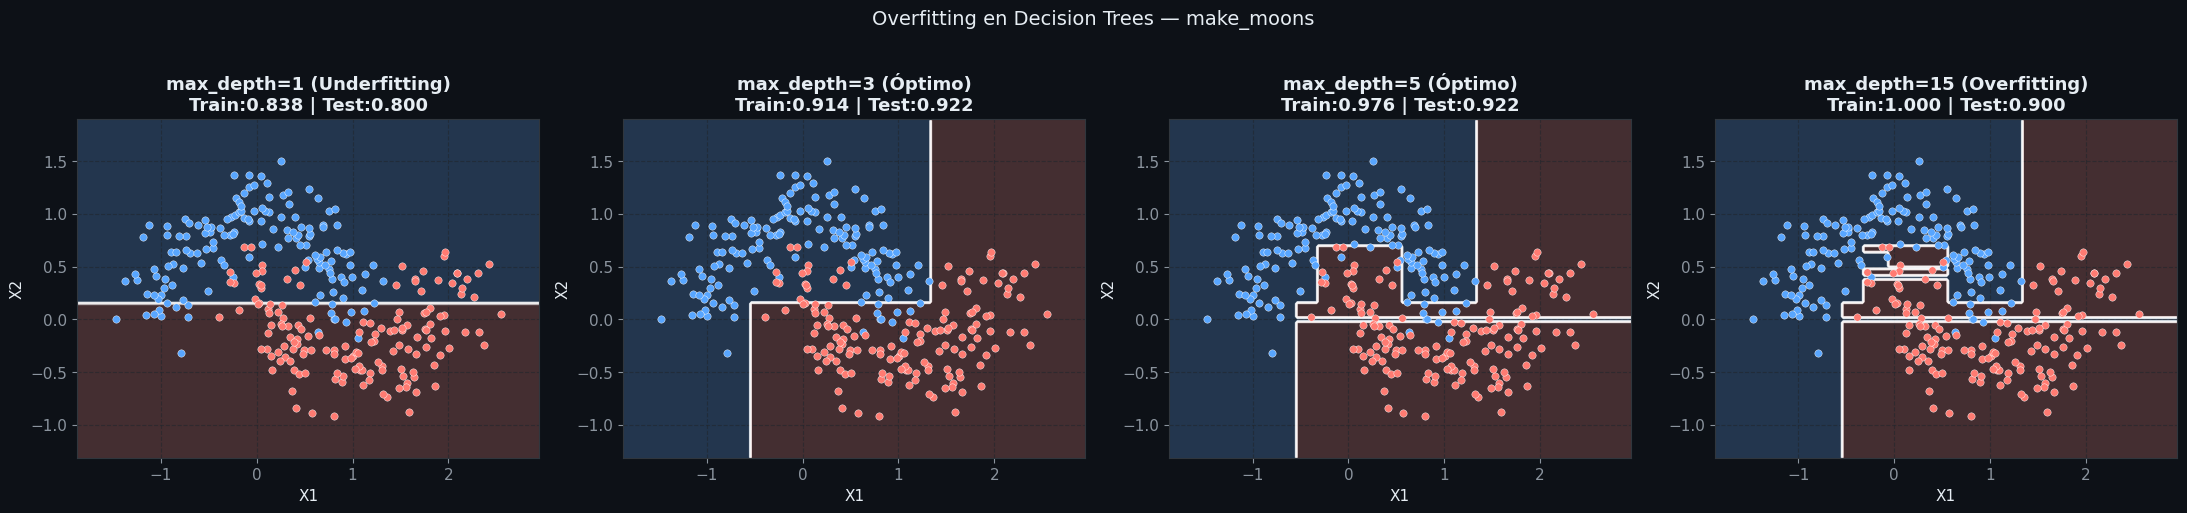

In [16]:
# ============================================================
#  Decision Tree en datos no lineales + Overfitting visual
# ============================================================

X_mn, y_mn = make_moons(n_samples=300, noise=0.2, random_state=42)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    X_mn, y_mn, test_size=0.3, random_state=42)

depths_moon = [1, 3, 5, 15]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Overfitting en Decision Trees — make_moons', fontsize=14, y=1.02)

h = 0.02
xm2, xM2 = X_mn[:, 0].min()-0.4, X_mn[:, 0].max()+0.4
ym2, yM2 = X_mn[:, 1].min()-0.4, X_mn[:, 1].max()+0.4
xx2, yy2 = np.meshgrid(np.arange(xm2, xM2, h), np.arange(ym2, yM2, h))

for ax, d in zip(axes, depths_moon):
    clf_m = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf_m.fit(Xm_tr, ym_tr)
    Zm = clf_m.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)

    cmap_m = ListedColormap([PALETTE[0] + '33', PALETTE[1] + '33'])
    ax.contourf(xx2, yy2, Zm, cmap=cmap_m)
    ax.contour(xx2, yy2, Zm, colors='white', linewidths=1, alpha=0.5)

    for cls, col in zip([0, 1], PALETTE[:2]):
        m = y_mn == cls
        ax.scatter(X_mn[m, 0], X_mn[m, 1], c=col, s=28,
                   edgecolors='white', lw=0.3, zorder=5)

    tr_a = clf_m.score(Xm_tr, ym_tr)
    te_a = clf_m.score(Xm_te, ym_te)
    label = '(Underfitting)' if d <= 1 else ('(Overfitting)' if d >= 10 else '(Óptimo)')
    ax.set_title(f'max_depth={d} {label}\nTrain:{tr_a:.3f} | Test:{te_a:.3f}')
    ax.set_xlabel('X1'); ax.set_ylabel('X2')
    ax.grid(True)
    ax.set_xlim(xm2, xM2); ax.set_ylim(ym2, yM2)

plt.tight_layout()
plt.savefig('dt_overfitting.png', dpi=110,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 6. Comparativa y Conclusiones

In [17]:
# ============================================================
#  COMPARATIVA FINAL — Scratch vs Clase vs Sklearn
# ============================================================

# Dataset Iris completo
X_cmp, y_cmp = X_iris, y_iris
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_cmp, y_cmp, test_size=0.25, random_state=42, stratify=y_cmp)

# ── 1. Scratch ──────────────────────────────────────────────
tree_s = build_tree(Xc_tr, yc_tr, max_depth=4,
                    min_samples_split=4, criterion='gini',
                    feature_names=feat_names)
acc_s  = np.mean(predict_tree(tree_s, Xc_te) == yc_te)

# ── 2. Clase OOP ────────────────────────────────────────────
clf_oop = DecisionTreeClasificador(max_depth=4, criterion='gini')
clf_oop.fit(Xc_tr, yc_tr)
acc_oop = clf_oop.score(Xc_te, yc_te)

# ── 3. Scikit-Learn ─────────────────────────────────────────
clf_ski = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
clf_ski.fit(Xc_tr, yc_tr)
acc_ski = clf_ski.score(Xc_te, yc_te)

# ── Scikit-Learn podado ──────────────────────────────────────
clf_pru = DecisionTreeClassifier(max_depth=4, ccp_alpha=0.01, random_state=42)
clf_pru.fit(Xc_tr, yc_tr)
acc_pru = clf_pru.score(Xc_te, yc_te)

print('='*58)
print('   COMPARATIVA FINAL — Iris Dataset (test 25%)')
print('='*58)
print(f'  DT desde Cero (funciones)  : {acc_s:.4f}')
print(f'  Clase DecisionTree (OOP)   : {acc_oop:.4f}')
print(f'  Scikit-Learn (sin poda)    : {acc_ski:.4f}')
print(f'  Scikit-Learn (con poda)    : {acc_pru:.4f}')
print('='*58)

   COMPARATIVA FINAL — Iris Dataset (test 25%)
  DT desde Cero (funciones)  : 0.9211
  Clase DecisionTree (OOP)   : 0.9211
  Scikit-Learn (sin poda)    : 0.9211
  Scikit-Learn (con poda)    : 0.9211


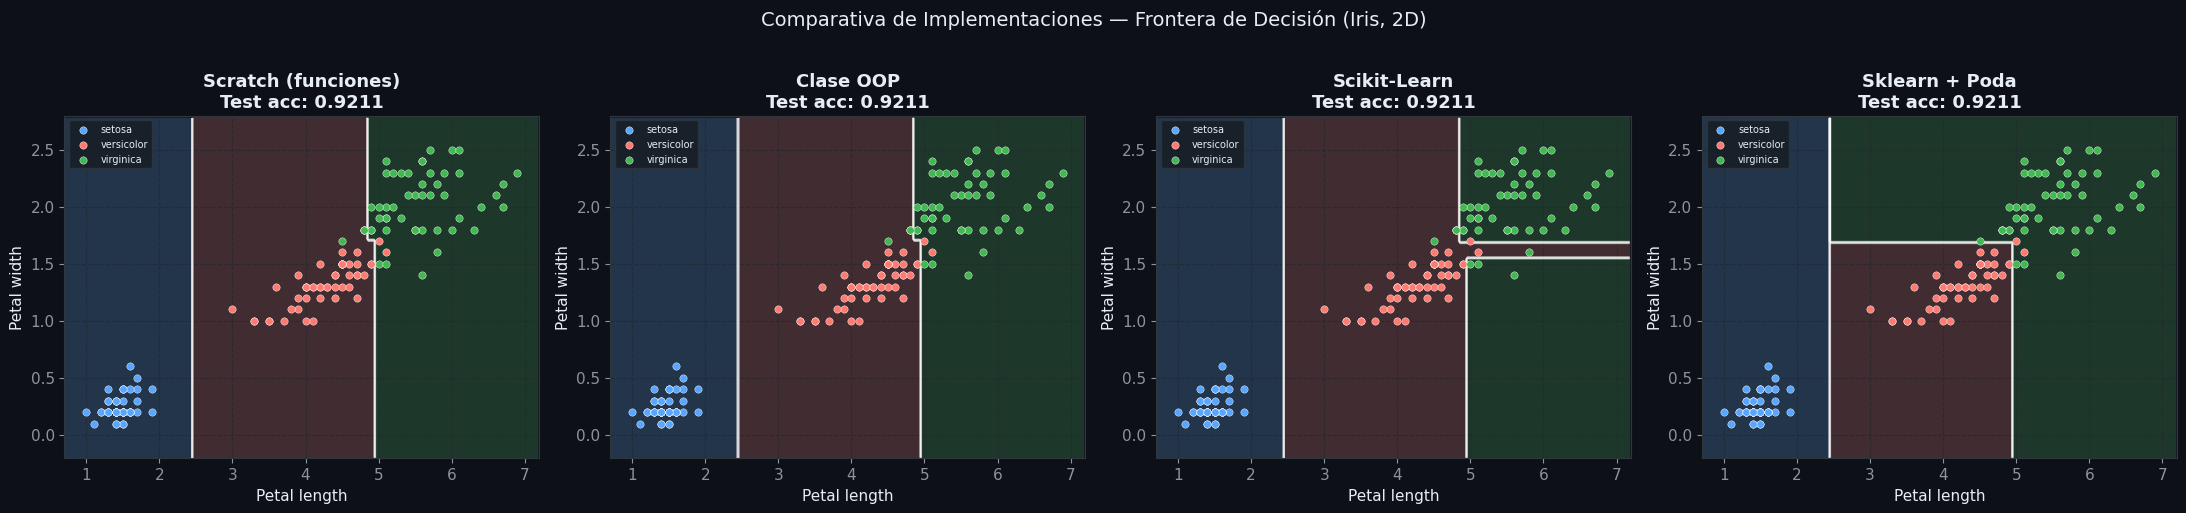

In [19]:
# ============================================================
#  GRÁFICO FINAL — Comparativa de fronteras
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Comparativa de Implementaciones — Frontera de Decisión (Iris, 2D)',
             fontsize=14, y=1.02)

# --- Re-entrenar modelos Scikit-Learn con 2 features para la visualización ---
sk_2d = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
sk_2d.fit(X2_tr, y2_tr)

sk_poda_2d = DecisionTreeClassifier(max_depth=4, ccp_alpha=0.01, random_state=42)
sk_poda_2d.fit(X2_tr, y2_tr)
# ------------------------------------------------------------------------------

titulos = [
    f'Scratch (funciones)\nTest acc: {acc_s:.4f}',
    f'Clase OOP\nTest acc: {acc_oop:.4f}',
    f'Scikit-Learn\nTest acc: {acc_ski:.4f}',
    f'Sklearn + Poda\nTest acc: {acc_pru:.4f}',
]

modelos = [
    ('scratch', tree2d),
    ('oop', clf_oop),
    ('sklearn', sk_2d), # Usar el modelo re-entrenado de 2 features
    ('sklearn_poda', sk_poda_2d), # Usar el modelo re-entrenado de 2 features
]

h  = 0.02
xm, xM = X2[:, 0].min()-0.3, X2[:, 0].max()+0.3
ym, yM = X2[:, 1].min()-0.3, X2[:, 1].max()+0.3
xx, yy = np.meshgrid(np.arange(xm, xM, h), np.arange(ym, yM, h))

for ax, (tipo, modelo), titulo in zip(axes, modelos, titulos):
    grid = np.c_[xx.ravel(), yy.ravel()]
    if tipo == 'scratch':
        m_oop_2d = DecisionTreeClasificador(max_depth=4, criterion='gini')
        m_oop_2d.fit(X2_tr, y2_tr)
        Z = m_oop_2d.predict(grid).reshape(xx.shape)
    elif tipo == 'oop':
        m2 = DecisionTreeClasificador(max_depth=4, criterion='gini')
        m2.fit(X2_tr, y2_tr)
        Z = m2.predict(grid).reshape(xx.shape)
    else: # Now 'modelo' already refers to the 2-feature trained model
        Z = modelo.predict(grid).reshape(xx.shape)

    cmap_bg = ListedColormap([PALETTE[0] + '30', PALETTE[1] + '30', PALETTE[2] + '30'])
    ax.contourf(xx, yy, Z, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=1.2, alpha=0.5)

    for cls, col, name in zip(range(3), PALETTE[:3], class_names):
        m = y_iris == cls
        ax.scatter(X2[m, 0], X2[m, 1], c=col, s=28,
                   edgecolors='white', lw=0.3, zorder=5, label=name)

    ax.set_title(titulo)
    ax.set_xlabel('Petal length'); ax.set_ylabel('Petal width')
    ax.set_xlim(xm, xM); ax.set_ylim(ym, yM)
    ax.grid(True)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('dt_comparativa_final.png', dpi=120,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# Conclusiones

## Comparativa de implementaciones

| Aspecto | Scratch | Clase OOP | Scikit-Learn |
|---|---|---|---|
| **Propósito** | Aprender la teoría | Reutilización educativa | Producción |
| **Regresión** | ❌ | ❌ | ✅ |
| **Poda (CCP)** | ❌ | ❌ | ✅ |
| **Multiclase** | ✅ | ✅ | ✅ |
| **Velocidad** | Lenta | Media | Muy rápida (Cython) |
| **Visualización** | ❌ | ❌ | ✅ `plot_tree` |

## Hiperparámetros clave

| Hiperparámetro | Efecto | Valor típico |
|---|---|---|
| `max_depth` | Controla overfitting | 3–10 |
| `min_samples_split` | Mínimo para dividir | 2–20 |
| `min_samples_leaf` | Regulariza hojas | 1–10 |
| `criterion` | Métrica de impureza | `gini` (más rápido) |
| `ccp_alpha` | Poda post-entrenamiento | validar con CV |

## Ventajas y limitaciones

✅ **Ventajas:**
- Interpretable y visualizable
- No requiere escalar los datos
- Maneja features numéricas y categóricas
- Captura relaciones no lineales
- Base de Random Forests y Gradient Boosting

⚠️ **Limitaciones:**
- Propenso a overfitting sin poda
- Alta varianza (sensible a cambios en datos)
- Fronteras de decisión en eje alineadas
- Inestable: pequeños cambios → árbol muy diferente

